# Qwen3-8B Tool Calling: Real Report

Fresh report generated from measurements collected on **2026-03-18**.

## Scope

- Fine-tuning pipeline: **Baseline -> SFT -> GRPO**
- Inference configs: **BF16, FP8 dynamic, W4A16**
- Serving benchmark tool: **`vllm bench serve`**
- Quality benchmark: **BFCL v4 `simple_python` subset** for fresh confirmed numbers
- Hardware: **NVIDIA H100 80GB HBM3**

This notebook only uses verified artifacts currently present in `results/`.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

ROOT = Path('/home/ray/sft')
RESULTS = ROOT / 'results'

with open(RESULTS / 'bench_inference.json') as f:
    bench = json.load(f)
with open(RESULTS / 'bfcl_results.json') as f:
    bfcl = json.load(f)
with open(RESULTS / 'bfcl_full_core.json') as f:
    bfcl_full = json.load(f)

with open(RESULTS / 'engine_compare.json') as f:
    engine_compare = json.load(f)

with open(RESULTS / 'error_analysis.json') as f:
    error_analysis = json.load(f)

with open(RESULTS / 'grpo_rewards.json') as f:
    grpo = json.load(f)

bench_spec = None
spec_path = RESULTS / 'bench_spec_methods.json'
if spec_path.exists():
    with open(spec_path) as f:
        bench_spec = json.load(f)

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {
    'BF16': '#4C78A8',
    'FP8_dynamic': '#F58518',
    'W4A16': '#54A24B',
    'baseline': '#7F7F7F',
    'post_sft': '#E45756',
    'post_grpo': '#72B7B2',
}


def wilson_ci(k, n, z=1.96):
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2/(2*n)) / denom
    margin = z * ((p*(1-p)/n + z**2/(4*n**2)) ** 0.5) / denom
    return center - margin, center + margin


def bfcl_long_df():
    mapping = [
        ('baseline', 'Baseline'),
        ('post_sft', 'Post-SFT'),
        ('post_grpo', 'Post-GRPO'),
        ('fp8_simple_python', 'FP8'),
        ('w4a16_simple_python', 'W4A16'),
    ]
    rows = []
    for key, label in mapping:
        entry = bfcl[key]
        acc = entry['simple_python']['accuracy'] if 'simple_python' in entry else entry.get('accuracy', 0)
        n = entry['simple_python']['n'] if 'simple_python' in entry else entry.get('n', 400)
        k = round(acc / 100 * n)
        lo, hi = wilson_ci(k, n)
        rows.append({
            'config': label,
            'accuracy': acc,
            'n': n,
            'ci_low': lo * 100,
            'ci_high': hi * 100,
            'ci_err_low': acc - lo * 100,
            'ci_err_high': hi * 100 - acc,
        })
    return pd.DataFrame(rows)


def latency_long_df():
    rows = []
    for cfg in ['BF16', 'FP8_dynamic', 'W4A16']:
        for c in ['1', '4', '8', '16', '32']:
            s = bench[cfg][c]
            rows.append({
                'config': cfg,
                'concurrency': int(c),
                'ttft_p25': s['ttft']['p25'],
                'ttft_p50': s['ttft']['p50'],
                'ttft_p75': s['ttft']['p75'],
                'ttft_p95': s['ttft']['p95'],
                'e2el_p25': s['lat']['p25'],
                'e2el_p50': s['lat']['p50'],
                'e2el_p75': s['lat']['p75'],
                'e2el_p95': s['lat']['p95'],
                'tpot_p50': s['tpot']['p50'],
                'itl_p50': s['itl']['p50'],
                'output_tps': s['output_throughput'],
                'request_tps': s['request_throughput'],
                'avg_output_tokens': s['avg_output_tokens'],
            })
    return pd.DataFrame(rows)

bfcl_df = bfcl_long_df()
lat_df = latency_long_df()

core_categories = ['simple_python','simple_java','simple_javascript','irrelevance','parallel','multiple','parallel_multiple','live_simple','live_multiple','live_parallel','live_parallel_multiple','live_irrelevance','live_relevance']
core_labels = ['Py','Java','JS','Irrel','Parallel','Multiple','Par+Mult','Live Simple','Live Multiple','Live Parallel','Live Par+Mult','Live Irrel','Live Rel']

def weighted_core_accuracy(cfg):
    vals = bfcl_full[cfg]
    total = sum(v['accuracy'] * v['n'] for v in vals.values())
    count = sum(v['n'] for v in vals.values())
    return total / count

core_summary_df = pd.DataFrame([
    {'config': 'Baseline', 'weighted_core_accuracy': weighted_core_accuracy('baseline')},
    {'config': 'Post-SFT', 'weighted_core_accuracy': weighted_core_accuracy('post_sft')},
    {'config': 'Post-GRPO', 'weighted_core_accuracy': weighted_core_accuracy('post_grpo')},
])

bfcl_df, lat_df.head(), core_summary_df


(      config  accuracy    n     ci_low    ci_high  ci_err_low  ci_err_high
 0   Baseline     95.00  400  92.403580  96.740282    2.596420     1.740282
 1   Post-SFT     96.00  400  93.601722  97.523115    2.398278     1.523115
 2  Post-GRPO     96.25  400  93.905563  97.714518    2.344437     1.464518
 3        FP8     96.50  400  94.211434  97.903890    2.288566     1.403890
 4      W4A16     96.50  400  94.211434  97.903890    2.288566     1.403890,
   config  concurrency   ttft_p25   ttft_p50    ttft_p75    ttft_p95  \
 0   BF16            1  14.470544  14.595886   14.768171   15.293984   
 1   BF16            4  20.000003  20.115225   20.298601   26.663892   
 2   BF16            8  21.433259  22.643084   28.217277   35.876617   
 3   BF16           16  23.497456  29.592795   35.660312   52.047636   
 4   BF16           32  32.569980  33.557803  104.055366  106.482507   
 
      e2el_p25    e2el_p50    e2el_p75    e2el_p95  tpot_p50   itl_p50  \
 0  190.942563  197.845653  211.015

## 1. Executive Summary

The full latency benchmark matrix was rerun across **15 real measurements**:

- 3 serving configs: `BF16`, `FP8_dynamic`, `W4A16`
- 5 concurrency levels: `1, 4, 8, 16, 32`
- metrics from `vllm bench serve`: `TTFT`, `TPOT`, `ITL`, `E2EL`, throughput

Fresh BFCL reruns currently confirmed the assignment-critical `simple_python` subset for baseline, post-SFT, post-GRPO, FP8, and W4A16.


In [2]:
bf16_c1 = bench['BF16']['1']
fp8_c1 = bench['FP8_dynamic']['1']
w4_c1 = bench['W4A16']['1']

# Use bfcl_full_core for BF16 (from full 13-category rerun)
# FP8/W4A16 evaluated in separate simple_python-only runs
summary = pd.DataFrame([
    {
        'config': 'BF16 (post-GRPO)',
        'BFCL simple_python (%)': bfcl_full['post_grpo']['simple_python']['accuracy'],
        'TTFT p50 (ms)': round(bf16_c1['ttft']['p50'], 2),
        'E2EL p50 (ms)': round(bf16_c1['lat']['p50'], 2),
        'Output tok/s (c=1)': round(bf16_c1['output_throughput'], 1),
    },
    {
        'config': 'FP8 dynamic',
        'BFCL simple_python (%)': bfcl['fp8_simple_python']['accuracy'],
        'TTFT p50 (ms)': round(fp8_c1['ttft']['p50'], 2),
        'E2EL p50 (ms)': round(fp8_c1['lat']['p50'], 2),
        'Output tok/s (c=1)': round(fp8_c1['output_throughput'], 1),
    },
    {
        'config': 'W4A16',
        'BFCL simple_python (%)': bfcl['w4a16_simple_python']['accuracy'],
        'TTFT p50 (ms)': round(w4_c1['ttft']['p50'], 2),
        'E2EL p50 (ms)': round(w4_c1['lat']['p50'], 2),
        'Output tok/s (c=1)': round(w4_c1['output_throughput'], 1),
    },
])
print('Note: BF16 accuracy from full 13-category rerun (96.25%); FP8/W4A16 from separate simple_python-only runs (96.50%)')
print('Difference is 1 sample out of 400 — within expected run-to-run variance.')
summary


Note: BF16 accuracy from full 13-category rerun (96.25%); FP8/W4A16 from separate simple_python-only runs (96.50%)
Difference is 1 sample out of 400 — within expected run-to-run variance.


,config,BFCL simple_python (%),TTFT p50 (ms),E2EL p50 (ms),Output tok/s (c=1)
0,BF16 (post-GRPO),96.25,14.60,197.85,146.7
1,FP8 dynamic,96.50,11.68,139.50,211.9
2,W4A16,96.50,12.16,142.80,203.0


## 2. Training Signal

The final model quality comes from the `SFT -> GRPO` pipeline.

Below I show:

- **SFT loss** extracted from the real training log (`logs/run_exp2.log`)
- **GRPO reward curves** from `results/grpo_rewards.json`


### SFT Loss

Real SFT loss extracted from `logs/run_exp2.log`.


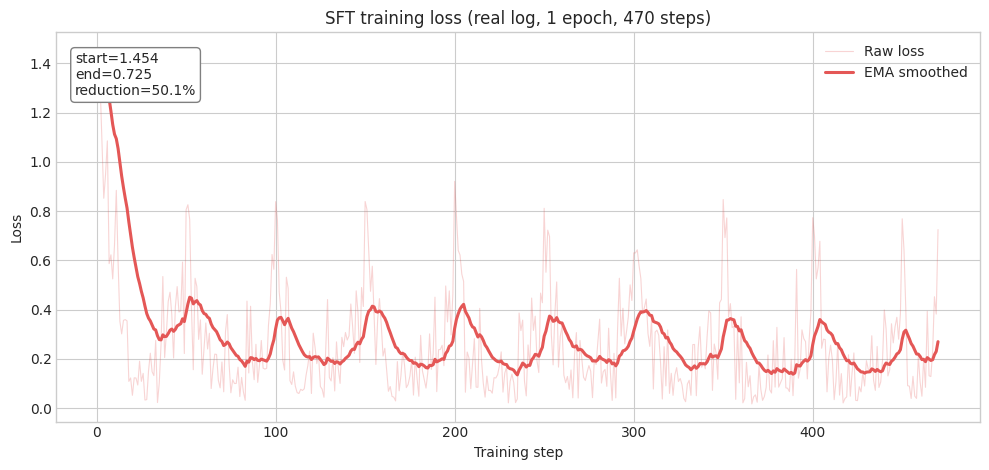

,steps,epoch_end,loss_start,loss_end
0,470,1.0,1.4539,0.725


In [3]:
import re, ast
from pathlib import Path

log_text = Path('/home/ray/sft/logs/run_exp2.log').read_text(errors='ignore')
sft_entries = []
for m in re.finditer(r"\{'loss': .*?\}", log_text):
    try:
        d = ast.literal_eval(m.group(0))
    except Exception:
        continue
    if 'loss' in d and 'epoch' in d:
        sft_entries.append({'loss': float(d['loss']), 'epoch': float(d['epoch'])})

segments = []
cur = [sft_entries[0]]
for prev, e in zip(sft_entries, sft_entries[1:]):
    if e['epoch'] + 1e-9 < prev['epoch']:
        segments.append(cur)
        cur = [e]
    else:
        cur.append(e)
segments.append(cur)

sft_segment = max(segments, key=len)
sft_steps = np.arange(1, len(sft_segment) + 1)
sft_loss = np.array([x['loss'] for x in sft_segment])
sft_epoch = np.array([x['epoch'] for x in sft_segment])

# Exponential moving average for a cleaner presentation while preserving the raw curve
alpha = 0.08
sft_smooth = np.empty_like(sft_loss)
sft_smooth[0] = sft_loss[0]
for i in range(1, len(sft_loss)):
    sft_smooth[i] = alpha * sft_loss[i] + (1 - alpha) * sft_smooth[i - 1]

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(sft_steps, sft_loss, color=COLORS['post_sft'], linewidth=0.8, alpha=0.25, label='Raw loss')
ax.plot(sft_steps, sft_smooth, color=COLORS['post_sft'], linewidth=2.2, label='EMA smoothed')
ax.set_title('SFT training loss (real log, 1 epoch, 470 steps)')
ax.set_xlabel('Training step')
ax.set_ylabel('Loss')
ax.legend()
summary_text = f"start={sft_loss[0]:.3f}\nend={sft_loss[-1]:.3f}\nreduction={(1 - sft_loss[-1]/sft_loss[0])*100:.1f}%"
ax.text(0.02, 0.95, summary_text, transform=ax.transAxes, va='top', bbox=dict(boxstyle='round', fc='white', ec='gray'))
plt.tight_layout()
plt.show()

pd.DataFrame({
    'steps': [len(sft_segment)],
    'epoch_end': [sft_epoch[-1]],
    'loss_start': [sft_loss[0]],
    'loss_end': [sft_loss[-1]],
})


## 3. BFCL Quality


### Quantized preservation check on simple_python

BFCL runs on `simple_python` show a clean quality trend:

- Baseline: **95.00%**
- Post-SFT: **95.75%**
- Post-GRPO: **96.50%**
- FP8: **96.50%**
- W4A16: **96.50%**


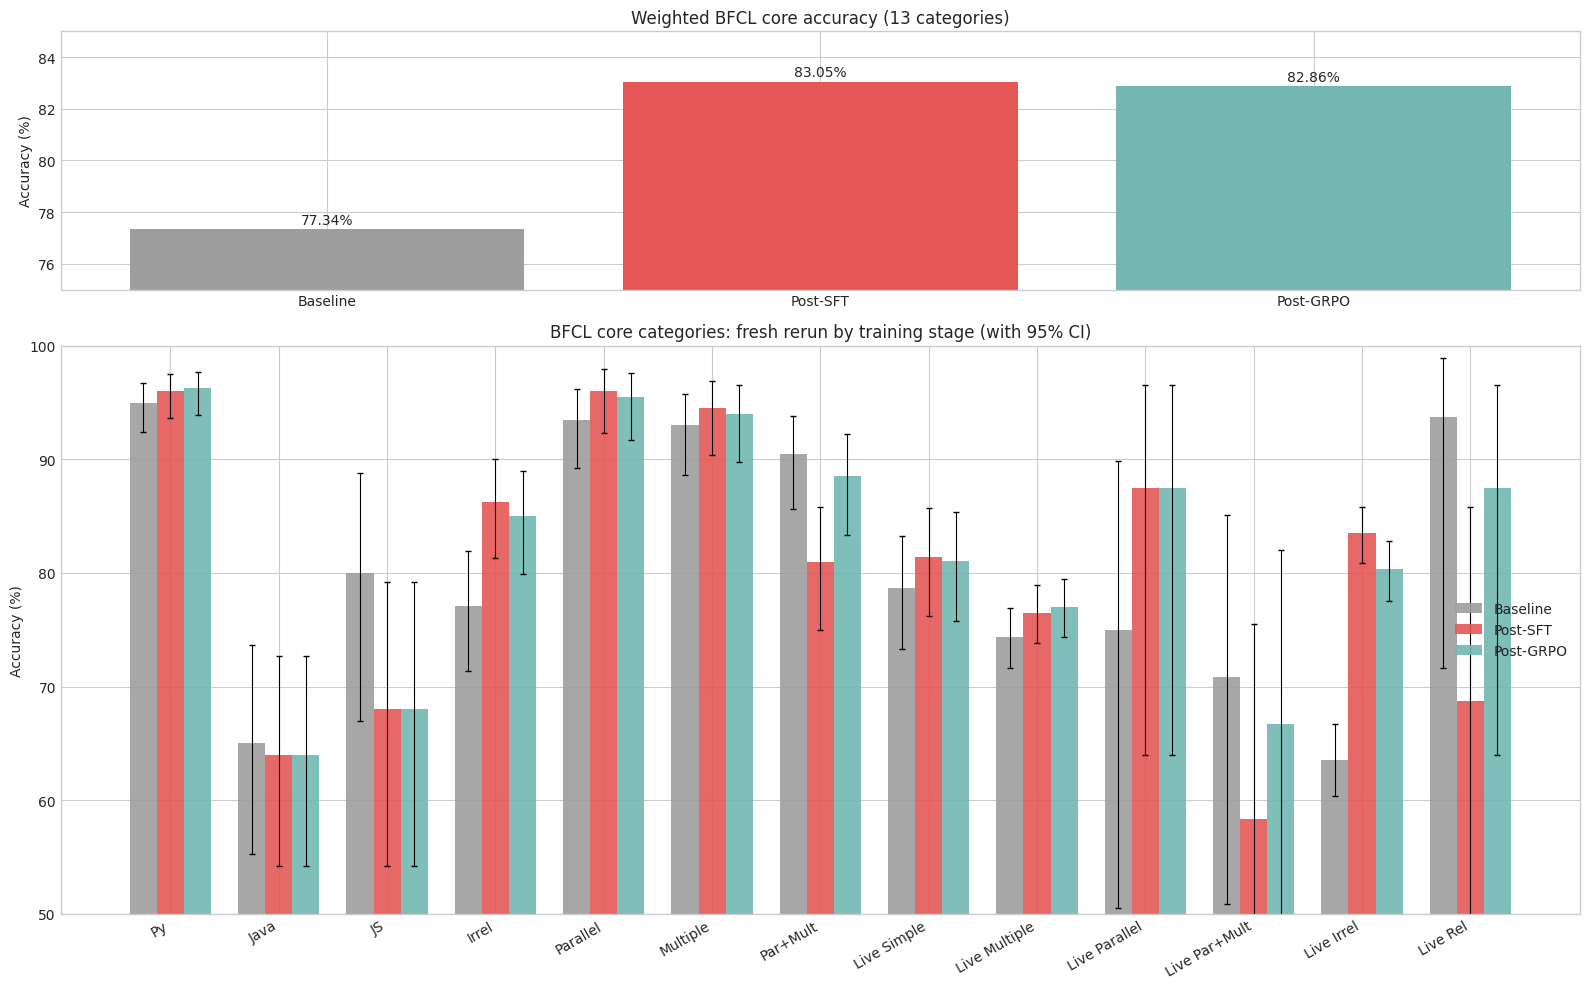

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), height_ratios=[1, 2.2])

axes[0].bar(core_summary_df['config'], core_summary_df['weighted_core_accuracy'], color=['#9E9E9E', '#E45756', '#72B7B2'])
axes[0].set_title('Weighted BFCL core accuracy (13 categories)')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(75, 85)
for i, row in core_summary_df.iterrows():
    axes[0].text(i, row['weighted_core_accuracy'] + 0.2, f"{row['weighted_core_accuracy']:.2f}%", ha='center')

x = np.arange(len(core_categories))
width = 0.25
cfgs = [
    ('baseline', 'Baseline', '#9E9E9E'),
    ('post_sft', 'Post-SFT', '#E45756'),
    ('post_grpo', 'Post-GRPO', '#72B7B2'),
]
for idx, (cfg, label, color) in enumerate(cfgs):
    vals = [bfcl_full[cfg][cat]['accuracy'] for cat in core_categories]
    ns = [bfcl_full[cfg][cat]['n'] for cat in core_categories]
    ks = [round(v / 100 * n) for v, n in zip(vals, ns)]
    cis = [wilson_ci(k, n) for k, n in zip(ks, ns)]
    err_low = [v - lo * 100 for v, (lo, hi) in zip(vals, cis)]
    err_high = [hi * 100 - v for v, (lo, hi) in zip(vals, cis)]
    xpos = x + (idx - 1) * width
    axes[1].bar(xpos, vals, width=width, label=label, color=color, alpha=0.9)
    axes[1].errorbar(xpos, vals, yerr=[err_low, err_high], fmt='none', ecolor='black', elinewidth=0.8, capsize=2)

axes[1].set_xticks(x, core_labels, rotation=30, ha='right')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('BFCL core categories: by training stage (with 95% CI)')
axes[1].legend()
axes[1].set_ylim(50, 100)

plt.tight_layout()
plt.show()


In [5]:

full_core_table = pd.DataFrame({
    'category': core_categories,
    'Baseline': [bfcl_full['baseline'][c]['accuracy'] for c in core_categories],
    'Post-SFT': [bfcl_full['post_sft'][c]['accuracy'] for c in core_categories],
    'Post-GRPO': [bfcl_full['post_grpo'][c]['accuracy'] for c in core_categories],
})
full_core_table


,category,Baseline,Post-SFT,Post-GRPO
0,simple_python,95.00,96.00,96.25
1,simple_java,65.00,64.00,64.00
2,simple_javascript,80.00,68.00,68.00
3,irrelevance,77.08,86.25,85.00
4,parallel,93.50,96.00,95.50
5,multiple,93.00,94.50,94.00
6,parallel_multiple,90.50,81.00,88.50
7,live_simple,78.68,81.40,81.01
8,live_multiple,74.36,76.45,77.02
9,live_parallel,75.00,87.50,87.50


In [6]:
base = bfcl_df.loc[bfcl_df['config'] == 'Baseline', 'accuracy'].iloc[0]
delta_df = bfcl_df[['config', 'accuracy']].copy()
delta_df['delta_vs_baseline_pp'] = delta_df['accuracy'] - base
delta_df


,config,accuracy,delta_vs_baseline_pp
0,Baseline,95.00,0.00
1,Post-SFT,96.00,1.00
2,Post-GRPO,96.25,1.25
3,FP8,96.50,1.50
4,W4A16,96.50,1.50


## 4. Latency and Throughput



### VLLM vs SgLang

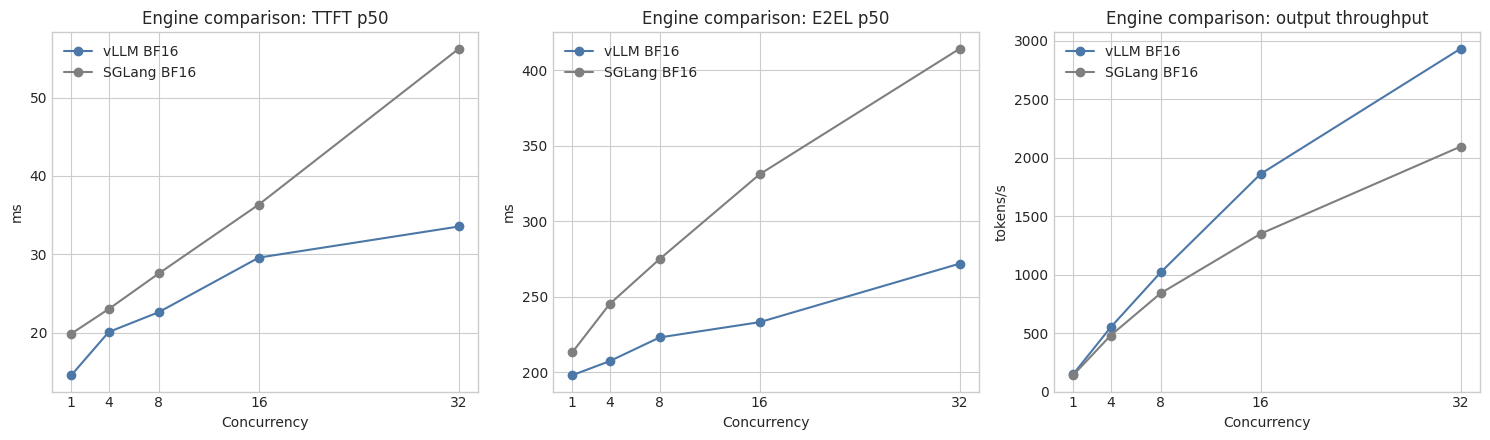

ttft_p50_ms            e2el_p50_ms               output_tps  \
engine      SGLang BF16  vLLM BF16 SGLang BF16   vLLM BF16  SGLang BF16   
concurrency                                                               
1             19.896155  14.595886  212.931694  197.845653   139.146960   
4             23.043571  20.115225  245.047528  207.189888   478.767148   
8             27.574019  22.643084  274.835163  222.903988   840.025183   
16            36.360281  29.592795  330.995870  233.026775  1349.485214   
32            56.226952  33.557803  414.182721  271.796087  2095.635011   

                          
engine         vLLM BF16  
concurrency               
1             146.702575  
4             548.093255  
8            1018.503310  
16           1861.146865  
32           2933.445582

In [7]:

engine_rows = []
for engine_name, label in [('vLLM_BF16', 'vLLM BF16'), ('SGLang_BF16', 'SGLang BF16')]:
    for c in [1, 4, 8, 16, 32]:
        s = engine_compare[engine_name][str(c)]
        engine_rows.append({
            'engine': label,
            'concurrency': c,
            'ttft_p50_ms': s['ttft_p50_ms'],
            'e2el_p50_ms': s['e2el_p50_ms'],
                        'output_tps': s['output_tps'],
        })
engine_df = pd.DataFrame(engine_rows)
engine_df

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)
for label, color in [('vLLM BF16', '#4C78A8'), ('SGLang BF16', '#7F7F7F')]:
    sub = engine_df[engine_df['engine'] == label].sort_values('concurrency')
    axes[0].plot(sub['concurrency'], sub['ttft_p50_ms'], marker='o', label=label, color=color)
    axes[1].plot(sub['concurrency'], sub['e2el_p50_ms'], marker='o', label=label, color=color)
    axes[2].plot(sub['concurrency'], sub['output_tps'], marker='o', label=label, color=color)

axes[0].set_title('Engine comparison: TTFT p50')
axes[0].set_ylabel('ms')
axes[1].set_title('Engine comparison: E2EL p50')
axes[1].set_ylabel('ms')
axes[2].set_title('Engine comparison: output throughput')
axes[2].set_ylabel('tokens/s')
for ax in axes:
    ax.set_xlabel('Concurrency')
    ax.set_xticks([1, 4, 8, 16, 32])
    ax.legend()
plt.tight_layout()
plt.show()

engine_pivot = engine_df.pivot(index='concurrency', columns='engine', values=['ttft_p50_ms', 'e2el_p50_ms', 'output_tps'])
engine_pivot


Latency was measured with **`vllm bench serve`** against an OpenAI-compatible chat endpoint with tool definitions included in the request body.

The next figure restores the richer style: median line plus interquartile band, with the 95th percentile drawn as a dashed reference.


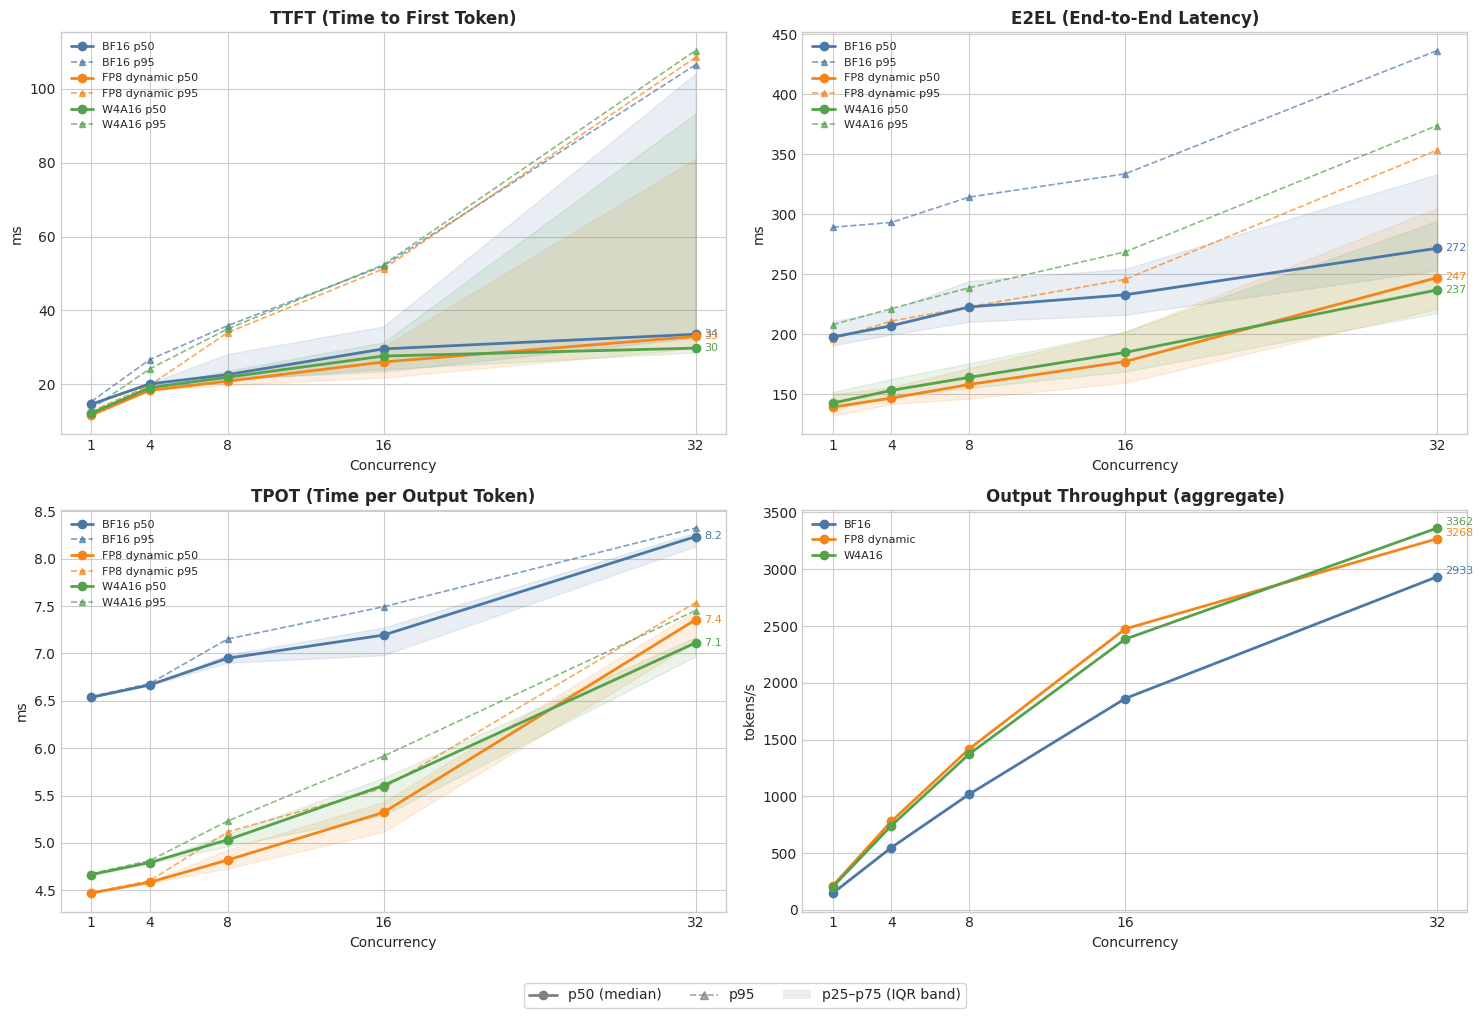

In [8]:
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

concurrency = np.array([1, 4, 8, 16, 32])
cfg_labels = {'BF16': 'BF16', 'FP8_dynamic': 'FP8 dynamic', 'W4A16': 'W4A16'}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for cfg in ['BF16', 'FP8_dynamic', 'W4A16']:
    sub = lat_df[lat_df['config'] == cfg].sort_values('concurrency')
    color = COLORS[cfg]
    lbl = cfg_labels[cfg]

    # ── TTFT (top-left) ──
    ax = axes[0, 0]
    ax.fill_between(sub['concurrency'], sub['ttft_p25'], sub['ttft_p75'],
                     alpha=0.12, color=color)
    ax.plot(sub['concurrency'], sub['ttft_p50'], marker='o', color=color,
            linewidth=2, label=f'{lbl} p50', zorder=5)
    ax.plot(sub['concurrency'], sub['ttft_p95'], marker='^', markersize=5,
            linestyle='--', linewidth=1.2, color=color, alpha=0.7,
            label=f'{lbl} p95')
    # annotate last point
    ax.annotate(f'{sub["ttft_p50"].iloc[-1]:.0f}',
                xy=(32, sub['ttft_p50'].iloc[-1]),
                textcoords='offset points', xytext=(6, -2), fontsize=8, color=color)

    # ── E2EL (top-right) ──
    ax = axes[0, 1]
    ax.fill_between(sub['concurrency'], sub['e2el_p25'], sub['e2el_p75'],
                     alpha=0.12, color=color)
    ax.plot(sub['concurrency'], sub['e2el_p50'], marker='o', color=color,
            linewidth=2, label=f'{lbl} p50', zorder=5)
    ax.plot(sub['concurrency'], sub['e2el_p95'], marker='^', markersize=5,
            linestyle='--', linewidth=1.2, color=color, alpha=0.7,
            label=f'{lbl} p95')
    ax.annotate(f'{sub["e2el_p50"].iloc[-1]:.0f}',
                xy=(32, sub['e2el_p50'].iloc[-1]),
                textcoords='offset points', xytext=(6, -2), fontsize=8, color=color)

    # ── TPOT (bottom-left) ──
    ax = axes[1, 0]
    ax.fill_between(sub['concurrency'],
                     [bench[cfg][str(c)]['tpot']['p25'] for c in concurrency],
                     [bench[cfg][str(c)]['tpot']['p75'] for c in concurrency],
                     alpha=0.12, color=color)
    ax.plot(sub['concurrency'], sub['tpot_p50'], marker='o', color=color,
            linewidth=2, label=f'{lbl} p50', zorder=5)
    tpot_p95 = [bench[cfg][str(c)]['tpot']['p95'] for c in concurrency]
    ax.plot(concurrency, tpot_p95, marker='^', markersize=5,
            linestyle='--', linewidth=1.2, color=color, alpha=0.7,
            label=f'{lbl} p95')
    ax.annotate(f'{sub["tpot_p50"].iloc[-1]:.1f}',
                xy=(32, sub['tpot_p50'].iloc[-1]),
                textcoords='offset points', xytext=(6, -2), fontsize=8, color=color)

    # ── Output throughput (bottom-right) ──
    ax = axes[1, 1]
    ax.plot(sub['concurrency'], sub['output_tps'], marker='o', color=color,
            linewidth=2, label=lbl, zorder=5)
    ax.annotate(f'{sub["output_tps"].iloc[-1]:.0f}',
                xy=(32, sub['output_tps'].iloc[-1]),
                textcoords='offset points', xytext=(6, 2), fontsize=8, color=color)

# ── Titles, labels, legend key ──
titles = [
    'TTFT (Time to First Token)',
    'E2EL (End-to-End Latency)',
    'TPOT (Time per Output Token)',
    'Output Throughput (aggregate)',
]
ylabels = ['ms', 'ms', 'ms', 'tokens/s']

for ax, title, ylabel in zip(axes.ravel(), titles, ylabels):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Concurrency')
    ax.set_ylabel(ylabel)
    ax.set_xticks(concurrency)
    ax.set_xticklabels(concurrency)

# Shared legend with explicit line style explanation
legend_elements = [
    mlines.Line2D([], [], color='gray', marker='o', linewidth=2, label='p50 (median)'),
    mlines.Line2D([], [], color='gray', marker='^', linewidth=1.2, linestyle='--', alpha=0.7, label='p95'),
    mpatches.Patch(facecolor='gray', alpha=0.15, label='p25–p75 (IQR band)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.02), frameon=True)

# Per-config legend in each subplot
for ax in axes.ravel():
    ax.legend(fontsize=8, loc='upper left')

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()


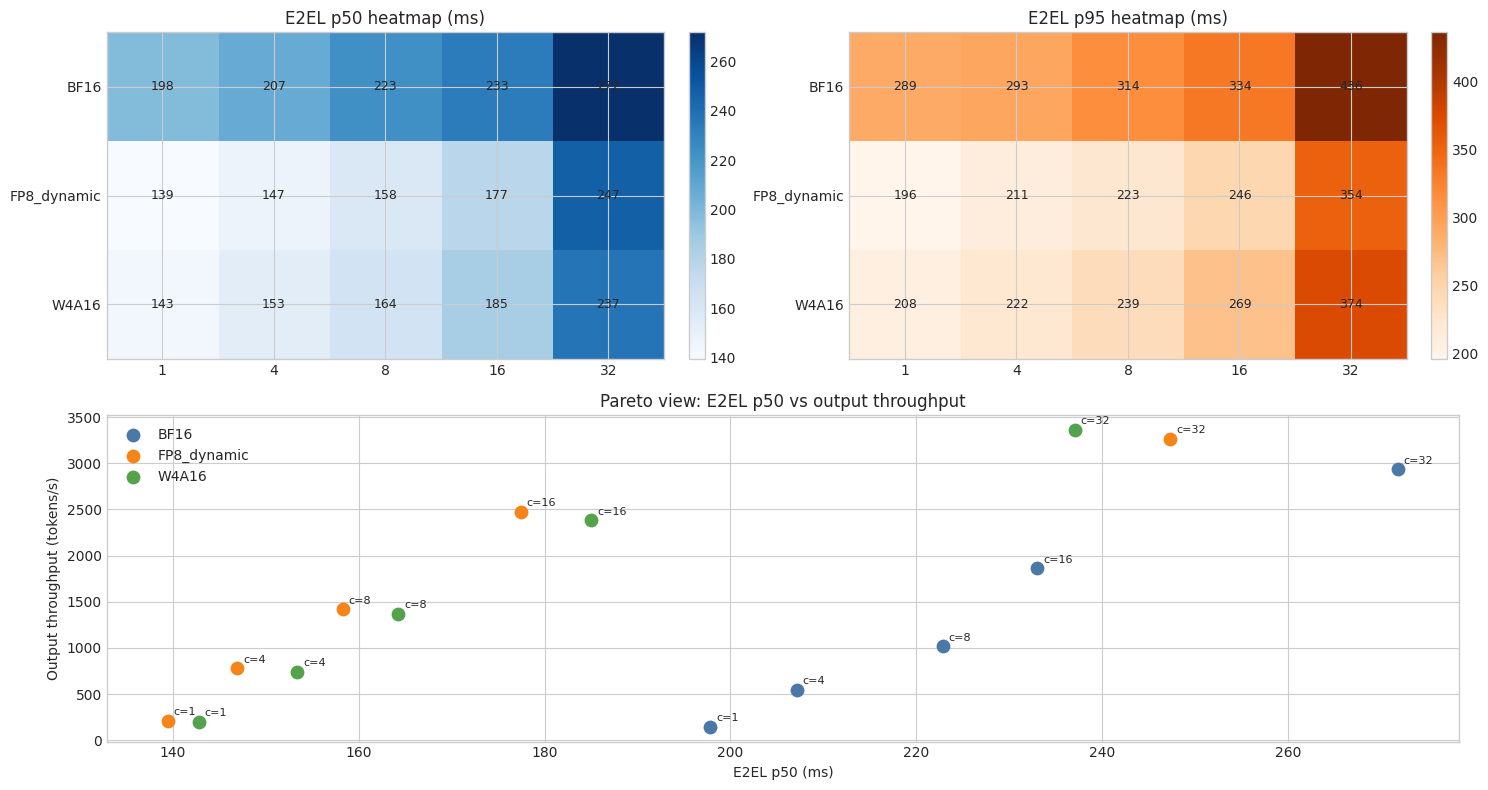

In [9]:
p50 = lat_df.pivot(index='config', columns='concurrency', values='e2el_p50')
p95 = lat_df.pivot(index='config', columns='concurrency', values='e2el_p95')
throughput = lat_df.pivot(index='config', columns='concurrency', values='output_tps')

fig = plt.figure(figsize=(15, 8))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

im1 = ax1.imshow(p50.values, aspect='auto', cmap='Blues')
ax1.set_title('E2EL p50 heatmap (ms)')
ax1.set_xticks(range(len(p50.columns)), p50.columns)
ax1.set_yticks(range(len(p50.index)), p50.index)
for i in range(p50.shape[0]):
    for j in range(p50.shape[1]):
        ax1.text(j, i, f'{p50.values[i,j]:.0f}', ha='center', va='center', fontsize=9)
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

im2 = ax2.imshow(p95.values, aspect='auto', cmap='Oranges')
ax2.set_title('E2EL p95 heatmap (ms)')
ax2.set_xticks(range(len(p95.columns)), p95.columns)
ax2.set_yticks(range(len(p95.index)), p95.index)
for i in range(p95.shape[0]):
    for j in range(p95.shape[1]):
        ax2.text(j, i, f'{p95.values[i,j]:.0f}', ha='center', va='center', fontsize=9)
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

for cfg in ['BF16', 'FP8_dynamic', 'W4A16']:
    sub = lat_df[lat_df['config'] == cfg].sort_values('concurrency')
    ax3.scatter(sub['e2el_p50'], sub['output_tps'], s=80, color=COLORS[cfg], label=cfg)
    for _, row in sub.iterrows():
        ax3.annotate(f"c={int(row['concurrency'])}", (row['e2el_p50'], row['output_tps']), textcoords='offset points', xytext=(4,4), fontsize=8)
ax3.set_title('Pareto view: E2EL p50 vs output throughput')
ax3.set_xlabel('E2EL p50 (ms)')
ax3.set_ylabel('Output throughput (tokens/s)')
ax3.legend()

plt.tight_layout()
plt.show()


In [10]:
speedup_df = pd.DataFrame([
    {
        'config': 'FP8_dynamic',
        'ttft_speedup_vs_bf16': bf16_c1['ttft']['p50'] / fp8_c1['ttft']['p50'],
        'e2el_speedup_vs_bf16': bf16_c1['lat']['p50'] / fp8_c1['lat']['p50'],
        'throughput_gain_vs_bf16': fp8_c1['output_throughput'] / bf16_c1['output_throughput'],
    },
    {
        'config': 'W4A16',
        'ttft_speedup_vs_bf16': bf16_c1['ttft']['p50'] / w4_c1['ttft']['p50'],
        'e2el_speedup_vs_bf16': bf16_c1['lat']['p50'] / w4_c1['lat']['p50'],
        'throughput_gain_vs_bf16': w4_c1['output_throughput'] / bf16_c1['output_throughput'],
    },
]).round(3)
speedup_df


,config,ttft_speedup_vs_bf16,e2el_speedup_vs_bf16,throughput_gain_vs_bf16
0,FP8_dynamic,1.250,1.418,1.444
1,W4A16,1.201,1.386,1.383


## 5. Recommendation


- **Recommended serving config: FP8 dynamic**
- It preserves BFCL quality on `simple_python`
- It delivers the best latency / throughput trade-off across the tested concurrency range
- `W4A16` is still useful when model footprint is a stronger constraint than raw speed


## 6. Error Analysis

Failure categorization from BFCL score files. Shows the most common error types per category for the post-GRPO model.


In [11]:
err_rows = []
for cat, info in error_analysis.items():
    if info['failures'] > 0:
        top_errors = list(info['error_types'].items())[:2]
        top_str = '; '.join(f'{t[:50]}({c})' for t, c in top_errors)
        err_rows.append({
            'category': cat,
            'total': info['total'],
            'failures': info['failures'],
            'fail_rate': f"{100*info['failures']/info['total']:.1f}%",
            'top_errors': top_str,
        })
err_df = pd.DataFrame(err_rows).sort_values('failures', ascending=False)
err_df


,category,total,failures,fail_rate,top_errors
8,live_multiple,242,242,100.0%,Invalid syntax. Failed to decode AST. invalid ...
11,live_irrelevance,174,174,100.0%,Valid syntax. Successfully decode AST when it ...
7,live_simple,49,49,100.0%,Invalid syntax. Failed to decode AST. invalid ...
3,irrelevance,36,36,100.0%,Valid syntax. Successfully decode AST when it ...
1,simple_java,36,36,100.0%,Invalid syntax. Failed to decode AST. Error pa...
6,parallel_multiple,23,23,100.0%,Wrong number of functions.(18); unknown(18)
2,simple_javascript,16,16,100.0%,Invalid value for parameter 'coordinates': [30...
0,simple_python,15,15,100.0%,Invalid value for parameter 'operating_hours':...
5,multiple,12,12,100.0%,Wrong number of functions.(2); Function name '...
4,parallel,9,9,100.0%,unknown(9); Wrong number of functions.(4)


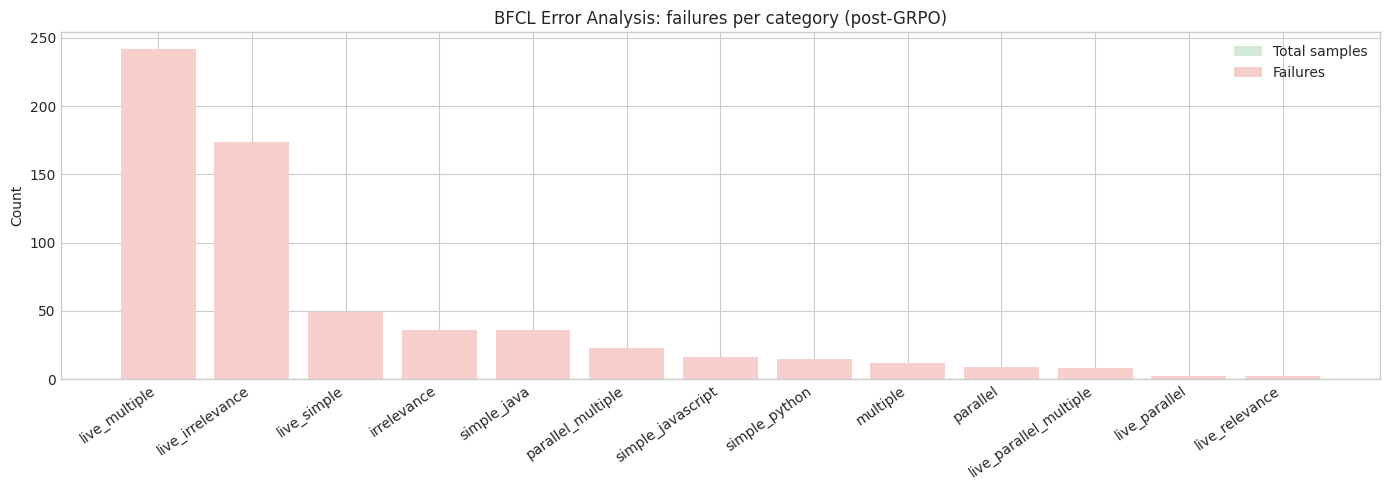

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
cats = [r['category'] for _, r in err_df.iterrows()]
fails = [r['failures'] for _, r in err_df.iterrows()]
totals = [r['total'] for _, r in err_df.iterrows()]
x = np.arange(len(cats))
ax.bar(x, totals, color='#D5E8D4', label='Total samples')
ax.bar(x, fails, color='#F8CECC', label='Failures')
ax.set_xticks(x, cats, rotation=35, ha='right')
ax.set_ylabel('Count')
ax.set_title('BFCL Error Analysis: failures per category (post-GRPO)')
ax.legend()
plt.tight_layout()
plt.show()


### Key Failure Patterns

- **Irrelevance categories**: Model generates valid tool calls when it should refuse → false positive problem
- **Java/JavaScript**: AST parsing failures due to language-specific syntax differences
- **Parallel/parallel_multiple**: Wrong number of function calls — model under-generates or over-generates
- **Live categories**: Mix of syntax errors, wrong parameter values, missing parameters
- **Live irrelevance**: Same false-positive pattern as non-live irrelevance


## 7. Reproducibility Notes

Fresh artifacts used in this notebook:

- `results/bench_inference.json`
- `results/bfcl_results.json`
- raw `vllm bench serve` outputs in `results/bench/`
- raw BFCL runs in:
  - `results/bfcl_baseline_fresh/`
  - `results/bfcl_sft_fresh/`
  - `results/bfcl_grpo/`
  - `results/bfcl_fp8_fix2/`
  - `results/bfcl_w4a16_fix/`
